# Churn Prediction Model — Full Pipeline

**Goal:** Predict whether a prospect will churn (Churned=1) or renew (Won=0) based on membership renewal call data and account features.

**Pipeline overview:**
1. Data loading & initial inspection
2. Filtering to closed outcomes only
3. Null analysis & column pruning
4. Feature engineering (binary flags, categorical encoding)
5. EDA — churn rate analysis per feature
6. Final feature selection & imputation
7. Model training (XGBoost) + threshold tuning
8. Evaluation & feature importance

## 1. Load Data

Load the merged dataset and immediately create a backup copy (`df_copy`).
This backup is used at the end to compare which columns were dropped versus added during the pipeline.

In [81]:
import pandas as pd

df = pd.read_csv("../../dataset/05_merged/final_latest_calls_fullcols.csv")
df.info()

# Backup for column-diff comparison at the end of the pipeline
df_copy = df.copy()

C:\Users\Asus\AppData\Local\Temp\ipykernel_26132\87473121.py:3: DtypeWarning: Columns (0: cc_contractor_sentiment_start_score_cc, 1: cc_contractor_sentiment_end_score_cc) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../dataset/05_merged/final_latest_calls_fullcols.csv")


<class 'pandas.DataFrame'>
RangeIndex: 122082 entries, 0 to 122081
Columns: 122 entries, Co_Ref to Call_Year_cc
dtypes: float64(26), int64(10), object(4), str(82)
memory usage: 113.6+ MB


## 2. Filter to Closed Outcomes Only

**WHY:** Rows with `Prospect_Outcome == 'Open'` represent ongoing/unresolved cases.
The target label for these rows is unknown — we cannot know yet whether they will churn or renew.
Including them would corrupt our supervised learning setup.
Only closed outcomes ('Won' = retained, 'Churned' = lost) provide a reliable ground truth label.

In [82]:
# Only include records with a definitive outcome — open cases have unknown labels
df = df[df['Prospect_Outcome'] != 'Open']

print("Remaining outcomes:", df['Prospect_Outcome'].unique())
print(f"Total columns: {len(df.columns)}")
print(f"Total rows after filtering: {len(df)}")

Remaining outcomes: <StringArray>
['Won', 'Churned']
Length: 2, dtype: str
Total columns: 122
Total rows after filtering: 113894


## 3. Null Analysis — Identify Columns to Drop

Calculate the percentage of null values per column.

**Drop strategy:**
- `> 95%` null → drop unconditionally (essentially empty columns — no imputation can save them)
- `80–95%` null → review manually; sparse but may encode rare, highly predictive events
- `< 80%` null → keep and handle via imputation or encoding later

In [83]:
null_percent = (df.isnull().sum() / len(df)) * 100
null_percent = null_percent.sort_values(ascending=False)

null_dict = null_percent.to_dict()
print(null_dict)

# Flag columns >70% null for further triage
high_null_dict = null_percent[null_percent > 70].to_dict()
print("\nColumns >70% null:")
print(high_null_dict)

# Auto-drop columns >95% null — practically empty, no imputation strategy is valid
cols_drop_95 = [col for col, val in high_null_dict.items() if val > 95]
df = df.drop(columns=cols_drop_95)
print(f"\nDropped {len(cols_drop_95)} columns with >95% nulls.")

{'Churn_Category_renewal': 99.06931006023144, 'Complaint_Category_renewal': 97.82956081970954, 'cc_issues_within_questionnaire_cc': 97.2772929214884, 'cc_contractor_complained_cc': 97.24305055577993, 'cc_contractor_suggest_leave_cc': 97.24305055577993, 'cc_contractor_sentiment_cc': 97.24305055577993, 'cc_care_package_cc': 97.23953851827137, 'cc_care_package_discussed_cc': 97.23953851827137, 'cc_urgency_getting_on_site_cc': 97.23953851827137, 'cc_external_consultant_cc': 97.23953851827137, 'cc_agent_cross_sell_attempt_cc': 97.23953851827137, 'cc_customer_issues_concerns_cc': 97.23953851827137, 'cc_business_struggles_financial_hardship_cc': 97.23953851827137, 'cc_call_initiated_by_cc': 97.23953851827137, 'cc_dissatisfaction_time_to_complete_cc': 97.23427046200854, 'cc_platform_issues_cc': 97.23427046200854, 'cc_login_issues_cc': 97.23427046200854, 'cc_process_complexity_concerns_cc': 97.23427046200854, 'cc_questions_harder_than_expected_cc': 97.23427046200854, 'cc_dissatisfaction_support

## 4. Clean Categorical Renewal Columns

Four key columns capture customer intent signals from the renewal call.
We standardise their string values (lowercase, strip whitespace, consistent labels)
before converting them to numeric flags.

**WHY clean first?** Raw data often has case inconsistencies ('Yes' vs 'yes' vs 'YES'),
leading to incorrect mappings or NaN values if not pre-processed.

In [84]:
import numpy as np

# ── 1. Explicit Switching Intent ─────────────────────────────
# Did the customer explicitly say they are considering switching to a competitor?
col = 'Explicit_Switching_Intent_renewal'
df[col] = (
    df[col].replace(np.nan, 'Unknown').astype(str)
    .str.strip().str.lower()
    .map({'yes': 'Yes', 'no': 'No', 'unknown': 'Unknown'})
    .fillna('Unknown')
)

# ── 2. Discount Offered ─────────────────────────────────────
# Was a retention discount offered by the agent during the renewal call?
col = 'Discount_Offered_renewal'
df[col] = (
    df[col].replace(np.nan, 'Unknown').astype(str)
    .str.strip().str.lower()
    .map({'yes': 'Yes', 'no': 'No', 'unknown': 'Unknown'})
    .fillna('Unknown')
)

# ── 3. Customer Response ────────────────────────────────────
# How did the customer respond to the renewal pitch overall?
col = 'Customer_Response_renewal'
df[col] = (
    df[col].replace(np.nan, 'Unknown').astype(str)
    .str.strip().str.lower()
    .map({'positive': 'Positive', 'negative': 'Negative', 'neutral': 'Neutral', 'unknown': 'Unknown'})
    .fillna('Unknown')
)

# ── 4. Desire To Cancel ─────────────────────────────────────
# Did the customer express desire to cancel their membership during the call?
col = 'Desire_To_Cancel_renewal'
df[col] = (
    df[col].replace(np.nan, 'Unknown').astype(str)
    .str.strip().str.lower()
    .map({'renewed': 'Renew', 'renew': 'Renew', 'desired to cancel': 'Cancel', 'unknown': 'Unknown'})
    .fillna('Unknown')
)

## 5. Create Binary Flags from Renewal Columns

Convert cleaned string columns to 0/1 binary flags for ML.

**WHY binary flags?**
- XGBoost requires numeric input
- Binary encoding cleanly captures presence/absence of each churn signal
- 'Unknown' → 0 because we cannot assume intent from missing data (safer than assuming churn)

**After flagging, drop original string columns** — all information is now captured numerically.

In [85]:
def binary_encode(col, mapping):
    """Standardise a column and map to binary 0/1. Unknown defaults to 0 (no signal)."""
    return (
        df[col].replace(np.nan, 'Unknown').astype(str)
        .str.strip().str.lower()
        .map(mapping).fillna(0)
    )

# 1 = customer expressed switching intent (strong churn signal)
df['Explicit_Switching_Intent_flag'] = binary_encode(
    'Explicit_Switching_Intent_renewal', {'yes': 1, 'no': 0, 'unknown': 0}
)

# 1 = agent offered discount (retention attempt was made — indirect churn risk indicator)
df['Discount_Offered_flag'] = binary_encode(
    'Discount_Offered_renewal', {'yes': 1, 'no': 0, 'unknown': 0}
)

# 1 = negative response (unhappy customer = higher churn risk)
df['Customer_Response_flag'] = binary_encode(
    'Customer_Response_renewal', {'negative': 1, 'positive': 0, 'neutral': 0, 'unknown': 0}
)

# 1 = customer expressed desire to cancel (very strong direct churn signal)
df['cancel_flag'] = binary_encode(
    'Desire_To_Cancel_renewal',
    {'desired to cancel': 1, 'cancel': 1, 'renew': 0, 'renewed': 0, 'unknown': 0}
)

# Drop original string columns — fully replaced by numeric flags above
df = df.drop(columns=[
    'Explicit_Switching_Intent_renewal',
    'Discount_Offered_renewal',
    'Customer_Response_renewal',
    'Desire_To_Cancel_renewal'
])

print(df['cancel_flag'].value_counts())

cancel_flag
0    112322
1      1572
Name: count, dtype: int64


## 6. Identify Sparse but Potentially Useful Columns

Columns between 80–95% null are sparse but not completely empty.
These need manual inspection before dropping — some rare events (e.g., a serious complaint)
are infrequent but extremely predictive of churn.

In [86]:
# Columns that are sparse but might contain meaningful rare signals — review before dropping
important_sparse_cols = [
    col for col, val in high_null_dict.items() if 80 < val <= 95
]
print("Sparse columns (80–95% null) for manual review:")
print(important_sparse_cols)

Sparse columns (80–95% null) for manual review:
['Agent_Response_Category_renewal', 'Customer_Renewal_Response_Category_renewal', 'Agent_Renewal_Pitch_Category_renewal', 'Serious_Complaint_renewal', 'Other_Complaint_renewal', 'Competitor_Benefits_Mentioned_renewal', 'Membership_Renewal_Decision_renewal', 'Renewal_Impact_Due_to_Price_Increase_renewal', 'Discount_or_Waiver_Requested_renewal', 'Discussion_on_Price_Increase_renewal', 'Agent_Renewal_Initiation_renewal', 'Agent_Flagged_Membership_Status_Alert_renewal', 'Call_Reschedule_Request_renewal', 'Price_Switching_Mentioned_renewal', 'Mentioned_Competitors_renewal', 'Explicit_Switching_Intent_renewal', 'Explicit_Competitor_Mention_renewal', 'Price_Range_Mentioned_renewal', 'Monetary_Price_Increase_Mentioned_renewal', 'Topic_Introduced_By_renewal', 'Customer_Asked_For_Justification_renewal', 'Customer_Response_renewal', 'Desire_To_Cancel_renewal', 'Discount_Offered_renewal', 'Percentage_Price_Increase_Mentioned_renewal', 'Analysed_Call_

## 7. Drop Administrative / ID Columns

**WHY drop these:**
- `Call_ID_renewal`, `Contact_ID_cc` — Unique row/contact identifiers. They carry zero predictive signal and would cause the model to overfit to individual IDs.
- `Call_Date_renewal`, `Prospect_Renewal_Date` — Raw datetime objects unusable by XGBoost. Any temporal signal (tenure, time elapsed) will be extracted separately as numeric features.

In [87]:
# ID columns: unique per row — no generalizable predictive signal, causes ID overfitting
# Date columns: raw timestamps — temporal signal extracted separately as numeric features
drop_cols = ['Call_ID_renewal', 'Contact_ID_cc', 'Call_Date_renewal', 'Prospect_Renewal_Date']

df = df.drop(columns=[col for col in drop_cols if col in df.columns])
print(f"Columns remaining: {len(df.columns)}")

Columns remaining: 84


## 8. Drop Redundant Financial Breakdown Columns

**WHY drop these:**
- `Starting_*` columns capture the price *before* renewal negotiation — highly correlated with current values, adding multicollinearity without new information.
- `Gross`, `Membership_Net`, `Package_Net`, `PQQNet`, `Amount` are all sub-components of the same total payment, each near-perfectly correlated with `Total_Net_Paid`.

**Hypothesis:** Financial commitment is best represented by a single clean metric (`Total_Net_Paid`). Multiple collinear versions of the same value confuse tree-based models by splitting the same signal across many features.

In [88]:
# Redundant financial sub-components — near-perfectly correlated with Total_Net_Paid
# Keeping multiple versions creates multicollinearity and dilutes feature importance scores
drop_financial = [
    'Starting_Vat', 'Starting_Gross', 'Starting_Membership_Net',
    'Starting_Package_Net', 'Starting_PQQ_Net', 'Starting_Net',
    'Gross', 'Membership_Net', 'Package_Net', 'PQQNet', 'Amount'
]

df = df.drop(columns=drop_financial, errors='ignore')
print(f"Columns remaining: {len(df.columns)}")

Columns remaining: 73


## 9. Create Target Variable

Encode the business outcome as a binary classification target:
- `Won` → **0** (customer retained / renewed)
- `Churned` → **1** (customer lost)

Drop the original string column after encoding.

In [89]:
# Binary target: 0 = Retained (Won), 1 = Churned
df['target'] = df['Prospect_Outcome'].map({'Won': 0, 'Churned': 1})

# Drop original string column — fully replaced by binary target
df = df.drop(columns=['Prospect_Outcome'])

print("Target distribution:")
print(df['target'].value_counts())
print(f"Churn rate: {df['target'].mean():.2%}")

Target distribution:
target
0    101226
1     12668
Name: count, dtype: int64
Churn rate: 11.12%


## 10. Feature Engineering — Days Since Registration

**Hypothesis:** Customers who registered longer ago are more deeply embedded in the platform,
have built more habits around it, and are therefore less likely to churn.
Converting the raw date difference into numeric days makes this temporal loyalty signal usable by the model.

In [90]:
# Convert to datetime
df['Closed_Date'] = pd.to_datetime(df['Closed_Date'], errors='coerce')
df['Registration_Date'] = pd.to_datetime(df['Registration_Date'], errors='coerce')

# Number of days from account registration to renewal decision date
# Acts as a proxy for account maturity / customer loyalty
df['days_since_registration'] = (df['Closed_Date'] - df['Registration_Date']).dt.days

print(df['days_since_registration'].describe())

count    112919.000000
mean       2497.895677
std        1966.710160
min       -1020.000000
25%         740.000000
50%        1876.000000
75%        3654.000000
max        9252.000000
Name: days_since_registration, dtype: float64


C:\Users\Asus\AppData\Local\Temp\ipykernel_26132\1224947252.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Closed_Date'] = pd.to_datetime(df['Closed_Date'], errors='coerce')
C:\Users\Asus\AppData\Local\Temp\ipykernel_26132\1224947252.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Registration_Date'] = pd.to_datetime(df['Registration_Date'], errors='coerce')


## 11. Drop Raw Date Columns

**WHY drop these:**
- XGBoost cannot process raw `datetime` objects — they must be converted to numbers first.
- All useful temporal information is already captured by:
  - `days_since_registration` (and later by `Tenure_Years` which is preferred)
- `DateTime_Out` is a call metadata timestamp — no direct causal link to churn outcome.

In [91]:
# Raw datetime columns — cannot be used directly by XGBoost
# Their useful signal (tenure, elapsed time) is already extracted as numeric features
date_cols = [
    'Proforma_Date', 'Registration_Date', 'Closed_Date',
    'Last_Renewal', 'Prev_Renewal_Date', 'DateTime_Out',
]
df = df.drop(columns=date_cols)

print(f"Columns remaining: {len(df.columns)}")

Columns remaining: 68


## 12. Encode Call Direction (Inbound vs Outbound)

**Hypothesis:**
- **Inbound** (customer called us): May indicate urgency, complaint, or the customer proactively planning to cancel — potentially higher churn signal.
- **Outbound** (we called them): Routine renewal outreach — customer was not proactively reaching out.

Encoded as: **0 = Inbound, 1 = Outbound**

In [92]:
# 0 = Inbound (customer initiated contact), 1 = Outbound (agent initiated contact)
df['Call_attend_status_renewal'] = (
    df['Call_Direction_renewal'].fillna('unknown')
    .astype(str).str.strip().str.lower()
    .apply(lambda x: 0 if x == 'inbound' else 1)
)

print(df['Call_attend_status_renewal'].value_counts())

# Drop original string column — encoded version captures all needed information
df = df.drop(columns=['Call_Direction_renewal'], errors='ignore')

Call_attend_status_renewal
1    112355
0      1539
Name: count, dtype: int64


## 13. EDA — Churn Rate by Key Categorical Features

Visualise churn rate across key categorical dimensions.
This gives us a business intuition about which customer segments are most at risk *before* fitting any model.


==== Payment_Method ====
target              0      1
Payment_Method              
BACS            100.0    0.0
CARD             93.2    6.8
CHEQUE          100.0    0.0
UNKNOWN           0.0  100.0
WORLD PAY       100.0    0.0

Counts:
 Payment_Method
CARD         71101
BACS         33191
UNKNOWN       7832
WORLD PAY     1699
CHEQUE          71
Name: count, dtype: int64


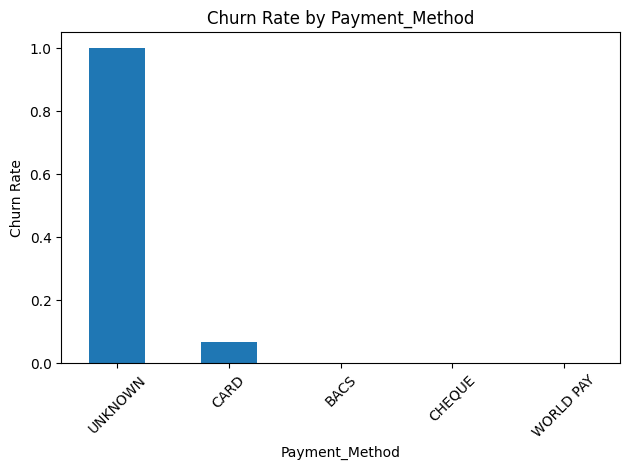


==== Band ====
target       0      1
Band                 
Band A   77.94  22.06
Band B   82.64  17.36
Band C1  89.02  10.98
Band C2  91.74   8.26
Band D   92.91   7.09
Band E   93.57   6.43
Band F   93.66   6.34
Band F1  93.82   6.18
Band F2  93.30   6.70
Band G   93.35   6.65
Band H   93.24   6.76
Band I   91.78   8.22
Band J   93.37   6.63
Group    94.19   5.81
Unknown   5.00  95.00

Counts:
 Band
Band B     30492
Band C1    23168
Band D     17720
Band C2    14737
Band E      9001
Band F1     5433
Band A      3523
Band F2     2939
Band G      2242
Band F      2193
Group        930
Band H       769
Band I       365
Band J       362
Unknown       20
Name: count, dtype: int64


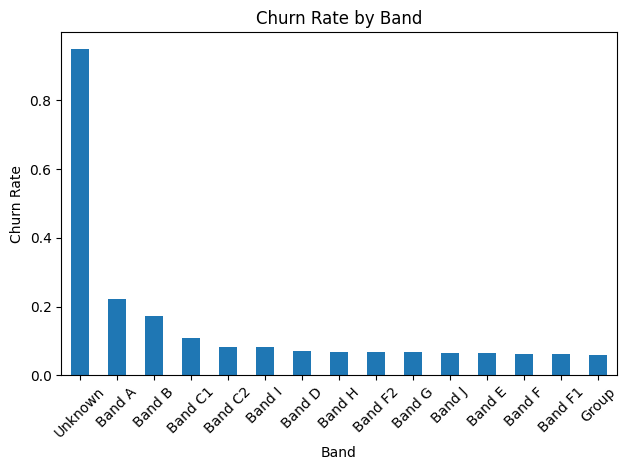


==== Connection_Group ====
target                0      1
Connection_Group              
1                 85.99  14.01
10+               97.77   2.23
2                 91.57   8.43
3                 94.11   5.89
4-9               96.12   3.88
Unknown           41.80  58.20
independent       80.13  19.87

Counts:
 Connection_Group
1              35435
independent    23118
4-9            19435
2              18167
3               9830
10+             7787
Unknown          122
Name: count, dtype: int64


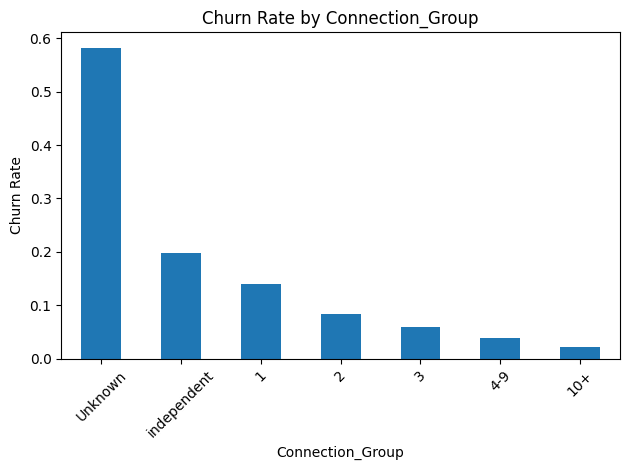


==== Tenure_Group ====
target            0      1
Tenure_Group              
1             78.19  21.81
2             84.00  16.00
3             86.23  13.77
4+            92.87   7.13
Unknown       87.59  12.41

Counts:
 Tenure_Group
4+         71422
1          18026
2          13198
3          10273
Unknown      975
Name: count, dtype: int64


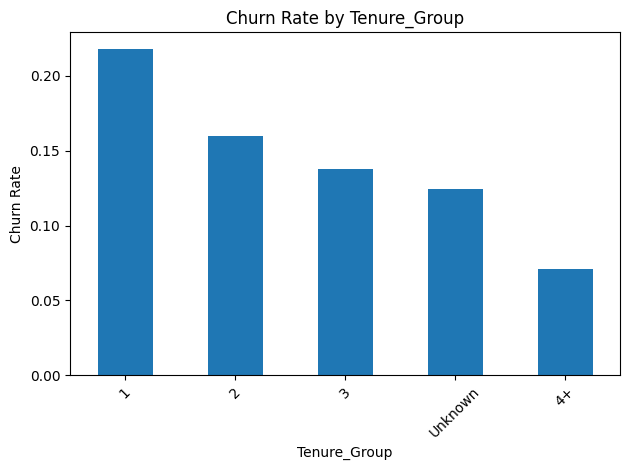


==== Anchor_Group ====
target            0      1
Anchor_Group              
1             85.99  14.01
10+           97.77   2.23
2             91.57   8.43
3             94.11   5.89
4-9           96.12   3.88
Unknown       41.80  58.20
independent   80.13  19.87

Counts:
 Anchor_Group
1              35435
independent    23118
4-9            19435
2              18167
3               9830
10+             7787
Unknown          122
Name: count, dtype: int64


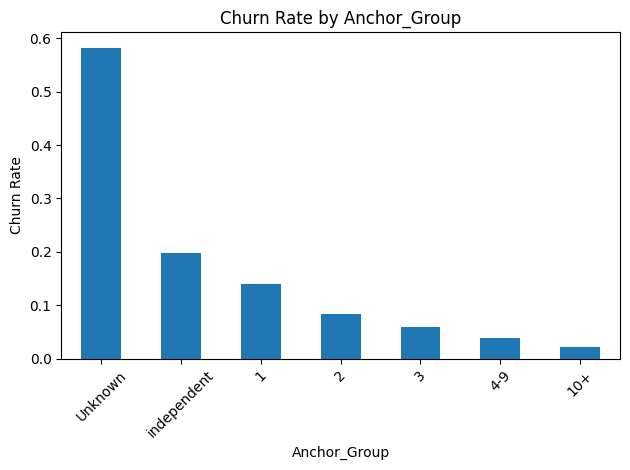

In [93]:
import matplotlib.pyplot as plt

cat_cols = ['Payment_Method', 'Band', 'Connection_Group', 'Tenure_Group', 'Anchor_Group']

for col in cat_cols:
    print(f"\n==== {col} ====")
    df[col] = df[col].fillna('Unknown')
    
    ct = pd.crosstab(df[col], df['target'], normalize='index') * 100
    print(ct.round(2))
    print("\nCounts:\n", df[col].value_counts())
    
    churn_rate = df.groupby(col)['target'].mean().sort_values(ascending=False)
    
    plt.figure()
    churn_rate.plot(kind='bar')
    plt.title(f"Churn Rate by {col}")
    plt.ylabel("Churn Rate")
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 14. Chi-Square Tests — Categorical vs Target

Quantify statistical association between categorical features and the binary target.

**Interpretation:**
- **High Chi2 + Low p-value** → Strong statistical dependence with churn → strong candidate to keep
- **Low Chi2 + High p-value** → No significant association → candidate for dropping

> ⚠️ Note: p-value significance is affected by sample size. Always check the actual churn rate *difference* too — a tiny difference can be statistically significant in large datasets but practically useless.

In [94]:
from scipy.stats import chi2_contingency

cat_cols = ['Payment_Method', 'Band', 'Connection_Group', 'Tenure_Group', 'Anchor_Group']
results = []

for col in cat_cols:
    table = pd.crosstab(df[col], df['target'])
    chi2, p, dof, expected = chi2_contingency(table)
    results.append((col, chi2, p))

res_df = pd.DataFrame(results, columns=['Feature', 'Chi2', 'p_value'])
res_df = res_df.sort_values('p_value')
print(res_df)

            Feature          Chi2  p_value
0    Payment_Method  68301.191365      0.0
1              Band   2721.465259      0.0
2  Connection_Group   4420.240766      0.0
3      Tenure_Group   3628.833560      0.0
4      Anchor_Group   4420.240766      0.0


## 15. EDA — Churn Rate by Number of Connections

**Hypothesis:** Customers with fewer connections have less platform dependency and lower switching costs — potentially easier to churn.
Customers with many connections have more to lose by leaving.

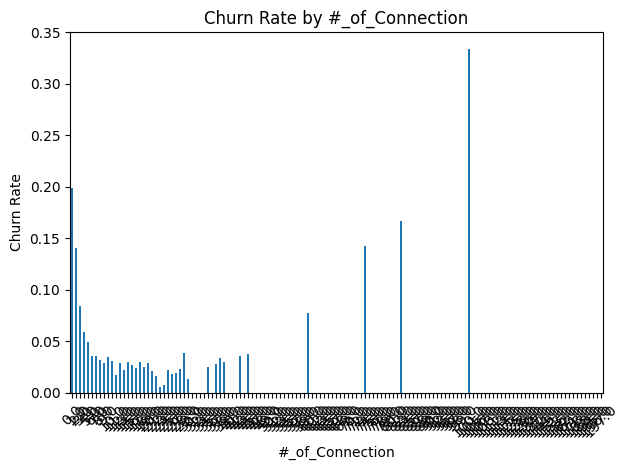

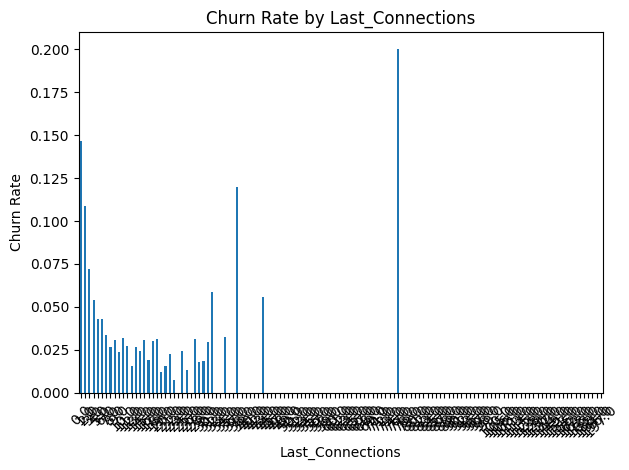

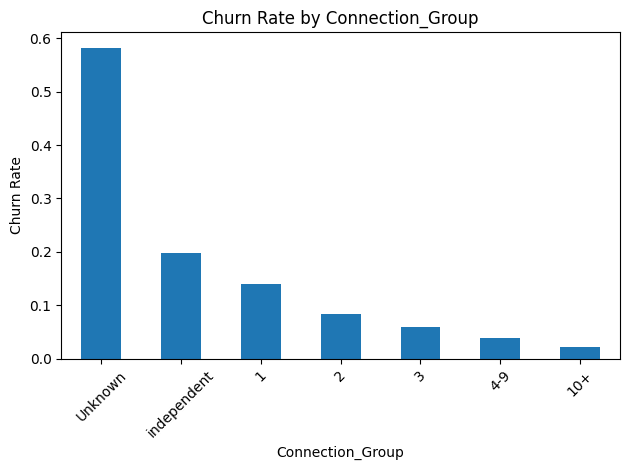

In [95]:
import matplotlib.pyplot as plt

for col, label in [('#_of_Connection', '#_of_Connection'), 
                    ('Last_Connections', 'Last_Connections'),
                    ('Connection_Group', 'Connection_Group')]:
    if col == 'Connection_Group':
        churn_rate = df.groupby(col)['target'].mean().sort_values(ascending=False)
    else:
        churn_rate = df.groupby(col)['target'].mean().sort_index()
    
    plt.figure()
    churn_rate.plot(kind='bar')
    plt.title(f"Churn Rate by {label}")
    plt.ylabel("Churn Rate")
    plt.xlabel(label)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 16. Point-Biserial Correlation — Connection Columns vs Target

Use **Point-Biserial Correlation** to measure linear association between numeric connection columns and the binary churn target.

**WHY Point-Biserial?** It is the appropriate correlation measure when one variable is binary (0/1 target) and the other is continuous or ordinal — a special case of Pearson's r.

In [96]:
from scipy.stats import pointbiserialr

cols = ['#_of_Connection', 'Last_Connections']

for col in cols:
    print(f"\n==== {col} ====")
    temp = df[[col, 'target']].dropna()
    corr, p = pointbiserialr(temp['target'], temp[col])
    print("Correlation:", round(corr, 4))
    print("p-value:", p)


==== #_of_Connection ====
Correlation: -0.1018
p-value: 1.5031852555041445e-259

==== Last_Connections ====
Correlation: -0.0846
p-value: 5.3707841702552703e-107


## 17. Drop Weak Connection & Payment Method Columns

**WHY drop `#_of_Connection` and `Last_Connections`:**
- Point-Biserial correlation with target is near-zero — no meaningful linear relationship
- Spurious statistical significance (large N inflates chi2/p-values without real effect)
- `Connection_Group` (the grouped/binned version) is retained as a cleaner alternative

**WHY drop `Payment_Method`:**
- High cardinality with no single dominant churn pattern
- Chi-square test showed weak association — noise rather than signal

In [97]:
# Near-zero correlation with target — weak predictors despite large sample significance
# Connection_Group (grouped version) retained as cleaner alternative
df = df.drop(columns=['#_of_Connection', 'Last_Connections', 'Payment_Method'])

print(f"Columns remaining: {len(df.columns)}")

Columns remaining: 65


## 18. Analyse & Drop Membership Renewal Decision — Data Leakage Risk

**WHY drop this column:**

This is a textbook case of **data leakage**. The field captures the actual renewal decision outcome — the same information encoded in our target variable.

- `Yes/No → ~100% churn rate` = perfect separation
- This column is filled *after* the outcome is known, not before the call
- Using it would produce artificially inflated model performance during training but **completely fail in production** (you will never have this field when predicting future churners at call time)

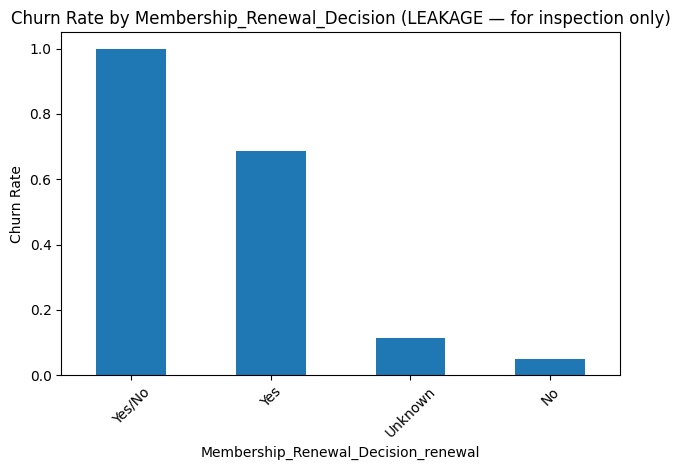

Chi2: 4648.22 | p-value: 0.0
DROPPING: This column encodes the outcome itself — direct data leakage.


In [98]:
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

df['Membership_Renewal_Decision_renewal'] = (
    df['Membership_Renewal_Decision_renewal'].fillna('Unknown').astype(str).str.strip()
)

churn_rate = (
    df.groupby('Membership_Renewal_Decision_renewal')['target']
    .mean().sort_values(ascending=False)
)

plt.figure()
churn_rate.plot(kind='bar')
plt.title("Churn Rate by Membership_Renewal_Decision (LEAKAGE — for inspection only)")
plt.ylabel("Churn Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

table = pd.crosstab(df['Membership_Renewal_Decision_renewal'], df['target'])
chi2, p, dof, expected = chi2_contingency(table)
print(f"Chi2: {chi2:.2f} | p-value: {p}")
print("DROPPING: This column encodes the outcome itself — direct data leakage.")

# DROP — encodes outcome directly, not available at prediction time
df = df.drop(columns=['Membership_Renewal_Decision_renewal'], errors='ignore')

## 19. Drop Analysed_Call Column

**WHY drop:**
- Boolean flag indicating whether an AI/human analysis was performed on the call recording
- This is a **process metadata flag** about how the data was generated, not about customer behaviour
- No clear business hypothesis linking call analysis status to churn probability

In [99]:
# Process metadata — reflects data pipeline status, not customer behaviour or intent
df = df.drop(columns=['Analysed_Call_renewal'])

print(f"Columns remaining: {len(df.columns)}")

Columns remaining: 63


## 20. EDA & Chi-Square — Competitor & Topic Columns

**Hypothesis:**
- **Competitor mentions** → Customer is actively comparing alternatives, evaluating switching, or expressing price/value dissatisfaction. All of these are strong churn signals.
- **Topic introduced by customer** → A customer who proactively raises the renewal topic may have already pre-decided to cancel, rather than being reactive to the agent.


==== Mentioned_Competitors_renewal ====
target                                                   0      1
Mentioned_Competitors_renewal                                    
44. The customer also mentioned that Safe Contr...  100.00   0.00
5% price increase is "quite a hefty hike for no...  100.00   0.00
NaN                                                  88.59  11.41
No                                                   91.16   8.84
XXXX                                                100.00   0.00
Yes                                                  83.23  16.77


C:\Users\Asus\AppData\Local\Temp\ipykernel_26132\76243564.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


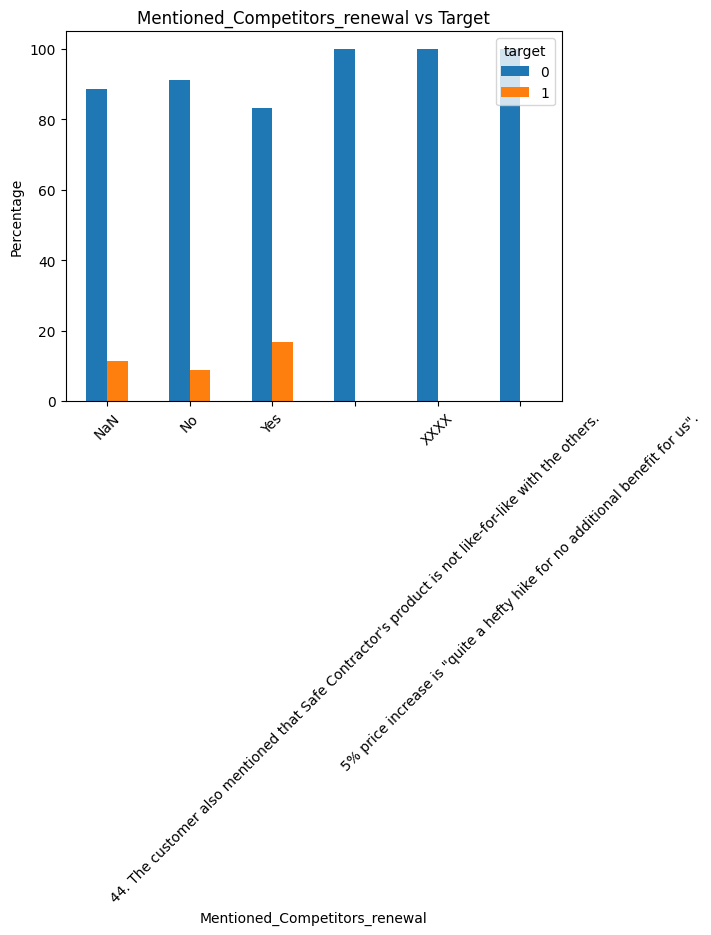


==== Competitor_Benefits_Mentioned_renewal ====
target                                                  0      1
Competitor_Benefits_Mentioned_renewal                           
Advice                                              100.0    0.0
Assistance                                          100.0    0.0
Better Accreditation                                100.0    0.0
Better Offering                                     100.0    0.0
Better Price                                         75.0   25.0
...                                                   ...    ...
The customer mentions that they can get better ...  100.0    0.0
The customer mentions that they can get similar...    0.0  100.0
The customer mentions that they were expecting ...  100.0    0.0
The customer mentions using the ECA for risk as...  100.0    0.0
better service                                      100.0    0.0

[86 rows x 2 columns]


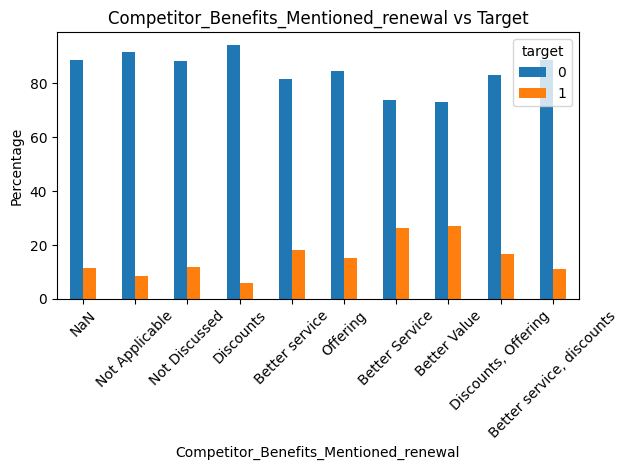


==== Topic_Introduced_By_renewal ====
target                           0      1
Topic_Introduced_By_renewal              
Agent                        92.69   7.31
Customer                     86.61  13.39
NaN                          88.59  11.41
Not Discussed                90.19   9.81


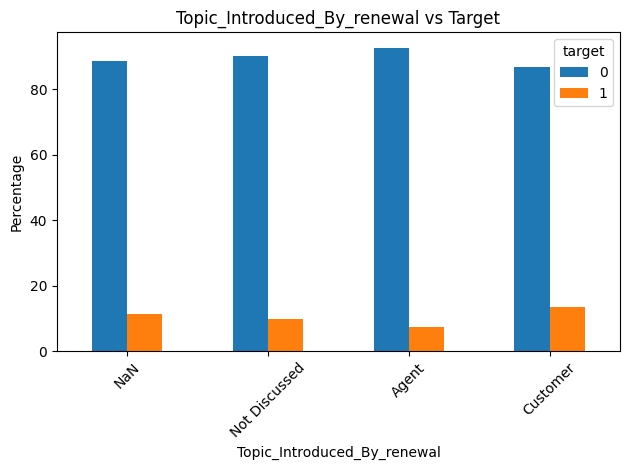


=== Chi-Square Results ===
                                 Feature  Chi2_Score       p_value
1  Competitor_Benefits_Mentioned_renewal  291.687224  1.867679e-24
0          Mentioned_Competitors_renewal  134.567009  2.552805e-27
2            Topic_Introduced_By_renewal   93.186187  4.529811e-20


In [100]:
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

cols = [
    'Mentioned_Competitors_renewal',
    'Competitor_Benefits_Mentioned_renewal',
    'Topic_Introduced_By_renewal'
]

results = []

for col in cols:
    if col not in df.columns:
        print(f"\n Skipping {col} (not in df)")
        continue
    
    print(f"\n==== {col} ====")
    ct = pd.crosstab(df[col].fillna('NaN'), df['target'], normalize='index') * 100
    print(ct.round(2))
    
    top_vals = df[col].fillna('NaN').value_counts().head(10).index
    ct.loc[top_vals].plot(kind='bar')
    plt.title(f'{col} vs Target')
    plt.xlabel(col)
    plt.ylabel('Percentage')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    contingency = pd.crosstab(df[col].fillna('NaN'), df['target'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    results.append({'Feature': col, 'Chi2_Score': chi2, 'p_value': p})

chi_df = pd.DataFrame(results).sort_values(by='Chi2_Score', ascending=False)
print("\n=== Chi-Square Results ===")
print(chi_df)

## 21. Create Competitor & Topic Binary Flags

Encode competitor and topic columns as binary flags.

**Note on `topic_agent_flag`:** This is created but dropped later because it is perfectly anticorrelated with `topic_customer_flag` (if customer=1, agent=0 and vice versa). Keeping both gives the model duplicate information.

In [101]:
# Any non-null value = competitor was mentioned during the call (strong churn signal)
df['competitor_mentioned_flag'] = df['Mentioned_Competitors_renewal'].notnull().astype(int)

# Customer raised renewal topic: signals pre-planned thinking about membership → churn risk
df['topic_customer_flag'] = (df['Topic_Introduced_By_renewal'] == 'Customer').astype(int)

# (Temporarily created; dropped below — perfectly anticorrelated with topic_customer_flag)
df['topic_agent_flag'] = (df['Topic_Introduced_By_renewal'] == 'Agent').astype(int)

# Drop original high-cardinality and noisy text columns — replaced by cleaner flags
df = df.drop(columns=[
    'Competitor_Benefits_Mentioned_renewal',  # Too much text variation — noise > signal
    'Mentioned_Competitors_renewal',           # Replaced by competitor_mentioned_flag
    'Topic_Introduced_By_renewal'              # Replaced by topic flags
], errors='ignore')

# Drop agent flag immediately — redundant with customer flag (perfectly anticorrelated)
df = df.drop(columns=['topic_agent_flag'], errors='ignore')

## 22. Analyse Account Stage & Create Risk Flags

**Hypothesis:**
- `Membership Only` / `Vetting` stages → thin platform ties, low switching cost → **high churn risk**
- `Published` stage → fully onboarded, invested in the platform → **low churn risk**

Collapsing the raw stage column into two risk flags is better than one-hot encoding all categories because:
1. It reduces dimensionality
2. It directly encodes domain knowledge about which stages are risky
3. Rare categories (<100 samples) are consolidated into 'Other' to avoid overfitting

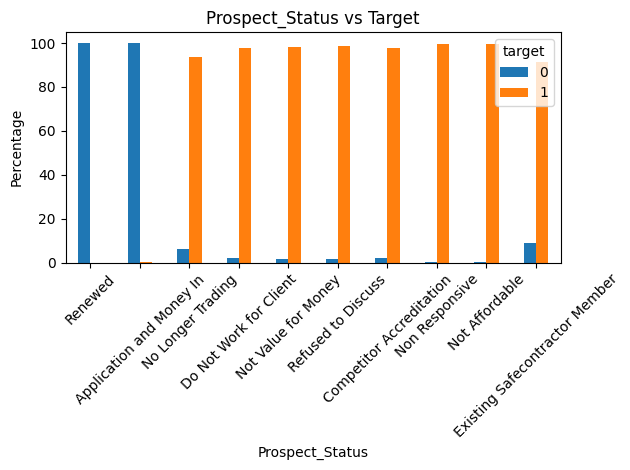

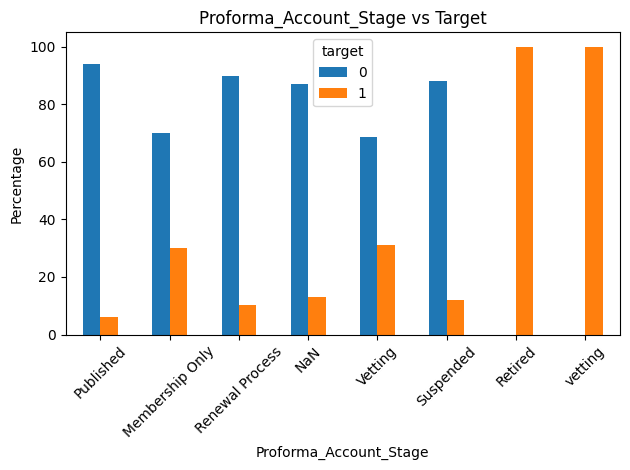

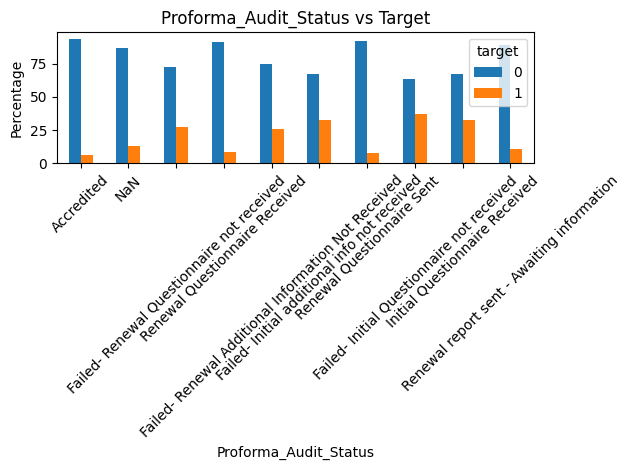

In [102]:
import matplotlib.pyplot as plt

# EDA: churn rate by account stage
for col in ['Prospect_Status', 'Proforma_Account_Stage', 'Proforma_Audit_Status']:
    if col not in df.columns:
        continue
    top_vals = df[col].fillna('NaN').value_counts().head(10).index
    ct = pd.crosstab(df[col].fillna('NaN'), df['target'], normalize='index') * 100
    ct.loc[top_vals].plot(kind='bar')
    plt.title(f'{col} vs Target')
    plt.ylabel('Percentage')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Standardise and consolidate rare categories (< 100 rows) to 'Other' — avoid overfitting
df['Proforma_Account_Stage'] = df['Proforma_Account_Stage'].str.strip().str.title()
counts = df['Proforma_Account_Stage'].value_counts()
rare = counts[counts < 100].index
df['Proforma_Account_Stage'] = df['Proforma_Account_Stage'].replace(rare, 'Other')

# High-risk: limited platform engagement, easier to leave
df['stage_high_risk_flag'] = df['Proforma_Account_Stage'].isin(['Membership Only', 'Vetting']).astype(int)

# Low-risk: fully onboarded and publicly listed — invested in the platform
df['stage_low_risk_flag'] = (df['Proforma_Account_Stage'] == 'Published').astype(int)

# Drop originals — risk flags capture the needed signal more cleanly
df = df.drop(columns=['Prospect_Status'])        # Weak chi2 signal
df = df.drop(columns=['Proforma_Account_Stage']) # Replaced by binary risk flags

## 23. Drop Remaining Weak / Leakage / Metadata Columns

A batch drop of columns identified as either leakage risks or statistically weak predictors:

| Column | Reason for Dropping |
|---|---|
| `Proforma_Audit_Status` | ⚠️ Likely leakage — status set *after* renewal decision is made |
| `Proforma_Membership_Status` | ⚠️ Same leakage concern — reflects outcome, not predictor |
| `Discussion_on_Price_Increase_renewal` | ❌ Low Chi2, high p-value — no meaningful churn separation |
| `Agent_Flagged_Membership_Status_Alert_renewal` | ❌ Weak signal — agent administrative flag, not customer behaviour |
| `Monetary_Price_Increase_Mentioned_renewal` | ❌ Signal already in `Renewal_Impact_Due_to_Price_Increase_renewal` |
| `Customer_Asked_For_Justification_renewal` | ❌ Weak Chi2 — rare event with minimal churn rate difference |
| `Percentage_Price_Increase_Mentioned_renewal` | ❌ Redundant with other price columns |
| `Price_Range_Mentioned_renewal` | ❌ Sparse + weak signal |

In [103]:
df = df.drop(columns=[
    # Leakage — status reflects outcome, not pre-outcome state
    'Proforma_Audit_Status',
    'Proforma_Membership_Status',

    # Weak predictors — low Chi2, minimal churn rate difference
    'Discussion_on_Price_Increase_renewal',
    'Agent_Flagged_Membership_Status_Alert_renewal',
    'Monetary_Price_Increase_Mentioned_renewal',
    'Customer_Asked_For_Justification_renewal',
    'Percentage_Price_Increase_Mentioned_renewal',
    'Price_Range_Mentioned_renewal'
], errors='ignore')

print(f"Columns remaining: {len(df.columns)}")

Columns remaining: 54


## 24. Drop Redundant Tenure & Score Columns

**WHY drop `Last_Band`:**
- Near-duplicate of current `Band` — correlation between current and previous band is very high
- Keeping both inflates feature count without adding new information

**WHY drop `Tenure_Scores`:**
- Derived from `Tenure_Years` — essentially the same information in a different scale
- `Tenure_Years` is cleaner and directly interpretable by humans and the model

In [104]:
# Last_Band ≈ Band (current) — near-duplicate, multicollinearity risk
df = df.drop(columns=['Last_Band'])

# Tenure_Scores is derived from Tenure_Years — same signal, less interpretable
df = df.drop(columns=['Tenure_Scores'])

print(f"Columns remaining: {len(df.columns)}")

Columns remaining: 52


## 25. Analyse & Drop World Pay Token Column

**Decision process for Proforma_World_Pay_Token:**
- p-value is statistically significant — but this is a large sample effect
- Actual churn rate difference between token/no-token groups is only ~0.7%
- **Decision: Drop** — misleadingly significant but practically useless signal

In [105]:
from scipy.stats import chi2_contingency

ct = pd.crosstab(df['Proforma_World_Pay_Token'], df['target'], normalize='index') * 100
print("World Pay Token vs Churn:")
print(ct.round(2))

table = pd.crosstab(df['Proforma_World_Pay_Token'], df['target'])
chi2, p, _, _ = chi2_contingency(table)
diff = df.groupby('Proforma_World_Pay_Token')['target'].mean().diff().iloc[-1]
print(f"Chi2: {chi2:.2f} | p-value: {p:.4f} | Churn rate diff: {diff:.4f}")
print("Decision: Drop — p-value significant but actual churn difference <1%, practically useless.")

# Drop — statistically significant due to large N, not due to real predictive power
df = df.drop(columns=['Proforma_World_Pay_Token'])

World Pay Token vs Churn:
target                        0      1
Proforma_World_Pay_Token              
False                     88.96  11.04
True                      89.67  10.33
Chi2: 11.78 | p-value: 0.0006 | Churn rate diff: -0.0071
Decision: Drop — p-value significant but actual churn difference <1%, practically useless.


## 26. Drop More Low-Signal Columns

| Column | Reason for Dropping |
|---|---|
| `Total_Renewal_Score_New` | Likely leakage — score possibly calculated using the outcome itself |
| `Proforma_Approved_Lists` | Internal platform admin metadata — no customer behaviour signal |
| `Agent_Renewal_Pitch_Category_renewal` | ~90% null — too sparse to train on reliably |
| `Agent_Renewal_Initiation_renewal` | Churn rate difference <1.1% — negligible signal |
| `Other_Complaint_renewal` | Signal already captured in `Serious_Complaint_renewal` and `agent_complaint_flag` |

In [106]:
# Likely leakage — score may incorporate outcome information
df = df.drop(columns=['Total_Renewal_Score_New'])

# Internal admin metadata — no customer behaviour signal
df = df.drop(columns=['Proforma_Approved_Lists'])

# ~90% null — not enough data to learn a reliable pattern
df.drop(columns=['Agent_Renewal_Pitch_Category_renewal'], inplace=True, errors='ignore')

# <1.1% churn rate difference — not worth the added dimensionality
df = df.drop(columns=['Agent_Renewal_Initiation_renewal'])

# Redundant — signal already in Serious_Complaint_renewal and agent_complaint_flag
df = df.drop(columns=['Other_Complaint_renewal'])

print(f"Columns remaining: {len(df.columns)}")

Columns remaining: 46


## 27. Create Agent Complaint Flag

**Hypothesis:** When the agent categorises a call as a 'Complaint' or 'Customer Service/Support' interaction,
it signals the agent perceived the customer as unhappy or frustrated — a leading indicator of churn.

We collapse the full `Agent_Response_Category_renewal` column into a single binary flag
to reduce cardinality while preserving the most predictive signal.

In [107]:
# Agent perceived the call as a complaint or support issue — strong proxy for customer dissatisfaction
df['agent_complaint_flag'] = df['Agent_Response_Category_renewal'].isin([
    'Complaints',
    'Customer Service / Support'
]).astype(int)

# Drop original high-cardinality column — replaced by binary flag
df = df.drop(columns=['Agent_Response_Category_renewal'])

print(df['agent_complaint_flag'].value_counts())

agent_complaint_flag
0    112705
1      1189
Name: count, dtype: int64


## 28. Encode Remaining Sparse Binary Signal Columns

Convert sparse Yes/No string columns to binary 0/1 flags.
**Null handling:** All nulls are treated as 'No' — the absence of a complaint or event is the normal/default state.

In [108]:
# Competitor explicitly named — stronger signal than just being mentioned
df['Explicit_Competitor_Mention_renewal'] = df['Explicit_Competitor_Mention_renewal'].fillna('No')
df['Explicit_Competitor_Mention_renewal'] = \
    df['Explicit_Competitor_Mention_renewal'].apply(lambda x: 1 if x == 'Yes' else 0)

# Customer mentioned price as reason for potentially switching
df['Price_Switching_Mentioned_renewal'] = df['Price_Switching_Mentioned_renewal'].fillna('No')
df['Price_Switching_Mentioned_renewal'] = \
    df['Price_Switching_Mentioned_renewal'].apply(lambda x: 1 if 'Yes' in str(x) else 0)

# Customer raised a formal or serious complaint during the call
df['Serious_Complaint_renewal'] = df['Serious_Complaint_renewal'].fillna('No').map({'No': 0, 'Yes': 1})

# Price increase was cited as reason for potential non-renewal
df['Renewal_Impact_Due_to_Price_Increase_renewal'] = \
    df['Renewal_Impact_Due_to_Price_Increase_renewal'].fillna('No') \
    .apply(lambda x: 1 if 'Yes' in str(x) else 0)

# Customer asked to be called back later — mild avoidance/delay signal
df['Call_Reschedule_Request_renewal'] = \
    df['Call_Reschedule_Request_renewal'].fillna('No').map({'No': 0, 'Yes': 1})

# Competitor value comparison: keep as category — 'similar value' vs 'not discussed' etc.
df['Competitor_Value_Comparison_renewal'] = df['Competitor_Value_Comparison_renewal'].fillna('unknown')

## 29. Drop Discount/Waiver Request Column

**WHY drop:**
- >80% null — dataset is too sparse for the model to learn a reliable pattern
- High text variation in values (many phrasings of the same concept) → noisy
- Discount information is already partially captured by `Discount_Offered_flag`

In [109]:
# Too sparse + high text variation + discount signal already in Discount_Offered_flag
df.drop(columns=['Discount_or_Waiver_Requested_renewal'], inplace=True, errors='ignore')

print(f"Columns remaining: {len(df.columns)}")

Columns remaining: 45


## 30. Engineer Customer Response Risk Tiers

Group `Customer_Renewal_Response_Category_renewal` into interpretable risk tiers based on business domain knowledge.

**WHY risk tiers instead of raw categories?**
- Reduces dimensionality and prevents overfitting to individual rare categories
- Injects domain knowledge directly into the feature
- Makes the model outputs more interpretable to business stakeholders

| Response Category | Risk Tier | Business Logic |
|---|---|---|
| Cancellation / Financial Hardship | High Risk | Direct churn intent or inability to pay |
| Confusion / Price / Quality | Medium Risk | Wavering — could go either way with intervention |
| Agreement / Auto / Payments | Low Risk | Routine renewal with no friction |
| (Other) | Neutral | No clear signal |
| Missing | Missing | No analysis was performed on this call |

In [110]:
def map_risk_improved(x):
    """Map raw renewal response category to churn risk tier using domain knowledge."""
    if x in ['Cancellation / Termination / Non-Renewal / Withdrawal',
             'Financial Hardship / Struggles']:
        return 'High Risk'
    elif x in ['Confusion / Uncertainty / Hesitation', 'Price and Cost',
               'Quality / Value / Satisfaction of service']:
        return 'Medium Risk'
    elif x in ['Agreement', 'Auto / Automatic', 'Payments and Billings / Invoice']:
        return 'Low Risk'
    elif x == 'Missing':
        return 'Missing'
    else:
        return 'Neutral'

df['Customer_Response_Risk'] = df['Customer_Renewal_Response_Category_renewal'].apply(map_risk_improved)

# Drop original high-cardinality column — replaced by risk tier
df = df.drop(columns=['Customer_Renewal_Response_Category_renewal'])

print(pd.crosstab(df['Customer_Response_Risk'], df['target']))

target                      0      1
Customer_Response_Risk              
High Risk                 253    463
Low Risk                 5857    169
Medium Risk              1944    277
Neutral                 93172  11759


## 31. Drop Call Sequencing & Temporal Metadata

**WHY drop these:**
- `Call_Number_renewal` — Sequence counter with no causal link to churn
- `Call_Year_renewal` — Year of call. Only useful for time-series models; our setup is cross-sectional
- `Renewal_Month`, `Renewal_Year` — Seasonal patterns are too weak to justify added noise in a cross-sectional model

In [111]:
print(df['Call_Number_renewal'].value_counts())

# Call sequence number — no causal connection to churn outcome
df = df.drop(columns=['Call_Number_renewal', 'Call_Year_renewal'])

# Renewal month/year — no clear seasonal churn mechanism in a cross-sectional model
df = df.drop(columns=['Renewal_Month', 'Renewal_Year'])

print(f"Columns remaining: {len(df.columns)}")

Call_Number_renewal
1.0      14778
2.0       8045
3.0       3559
4.0       1826
5.0        968
6.0        613
7.0        427
8.0        298
9.0        218
10.0       181
11.0       113
12.0       106
13.0        74
14.0        65
15.0        53
16.0        47
17.0        37
18.0        24
19.0        18
20.0        17
23.0        15
21.0        12
24.0        11
25.0        10
31.0         9
26.0         8
22.0         8
32.0         6
29.0         6
27.0         6
35.0         4
34.0         4
38.0         4
30.0         4
33.0         3
45.0         2
39.0         2
43.0         2
28.0         2
165.0        1
51.0         1
44.0         1
59.0         1
41.0         1
36.0         1
53.0         1
47.0         1
46.0         1
85.0         1
40.0         1
Name: count, dtype: int64
Columns remaining: 41


## 32. Log-Transform Payment Timeframe

**WHY transform:**
- `Payment_Timeframe` (days late/early vs due date) has heavy outliers — e.g., severely overdue payments
- Log transformation compresses the tail, reduces skewness, and makes the feature behave more predictably for the model
- `np.sign * log1p(abs(...))` safely handles both positive (late) and negative (early) payment values

In [112]:
print("Before transform:")
print(df['Payment_Timeframe'].describe())

# Signed log transformation: preserves sign (early/late), compresses outliers
df['Payment_Timeframe'] = np.sign(df['Payment_Timeframe']) * np.log1p(abs(df['Payment_Timeframe']))

print("\nAfter transform:")
print(df['Payment_Timeframe'].describe())

Before transform:
count    101226.000000
mean         -7.585541
std          54.586616
min      -10610.000000
25%         -15.000000
50%           0.000000
75%           0.000000
max         482.000000
Name: Payment_Timeframe, dtype: float64

After transform:
count    101226.000000
mean         -0.787647
std           2.307211
min          -9.269646
25%          -2.772589
50%           0.000000
75%           0.000000
max           6.180017
Name: Payment_Timeframe, dtype: float64


## 33. Column Type Summary

Review the current split of numeric vs categorical columns before correlation analysis and final encoding.

In [113]:
num_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numeric columns ({len(num_cols)}):")
print(num_cols)
print(f"\nCategorical columns ({len(cat_cols)}):")
print(cat_cols)

Numeric columns (29):
['Sustainability_Score', 'Last_Years_Price', 'Auto_Renewal_Score', 'Status_Scores', 'Anchoring_Score', 'Current_Anchorings', 'Payment_Timeframe', 'Renewal_Score_At_Release', 'Tenure_Years', 'Total_Net_Paid', 'Total_Amount', 'Last_Total_Net_Paid', 'Serious_Complaint_renewal', 'Renewal_Impact_Due_to_Price_Increase_renewal', 'Call_Reschedule_Request_renewal', 'Explicit_Competitor_Mention_renewal', 'Price_Switching_Mentioned_renewal', 'Explicit_Switching_Intent_flag', 'Discount_Offered_flag', 'Customer_Response_flag', 'cancel_flag', 'target', 'days_since_registration', 'Call_attend_status_renewal', 'competitor_mentioned_flag', 'topic_customer_flag', 'stage_high_risk_flag', 'stage_low_risk_flag', 'agent_complaint_flag']

Categorical columns (12):
['Co_Ref', 'Discount_Amount', 'Proforma_Auto_Renewal', 'Current_Anchor_List', 'Current_Auto_Renewal_Flag', 'Current_World_Pay_Token', 'Band', 'Connection_Group', 'Tenure_Group', 'Anchor_Group', 'Competitor_Value_Comparison_ren

C:\Users\Asus\AppData\Local\Temp\ipykernel_26132\1404994355.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


## 34. Correlation Heatmap

Visualise pairwise correlations across all numeric features to:
1. Identify highly correlated feature pairs (>0.9) — candidates for redundancy removal
2. See which features have the strongest direct correlation with the churn target

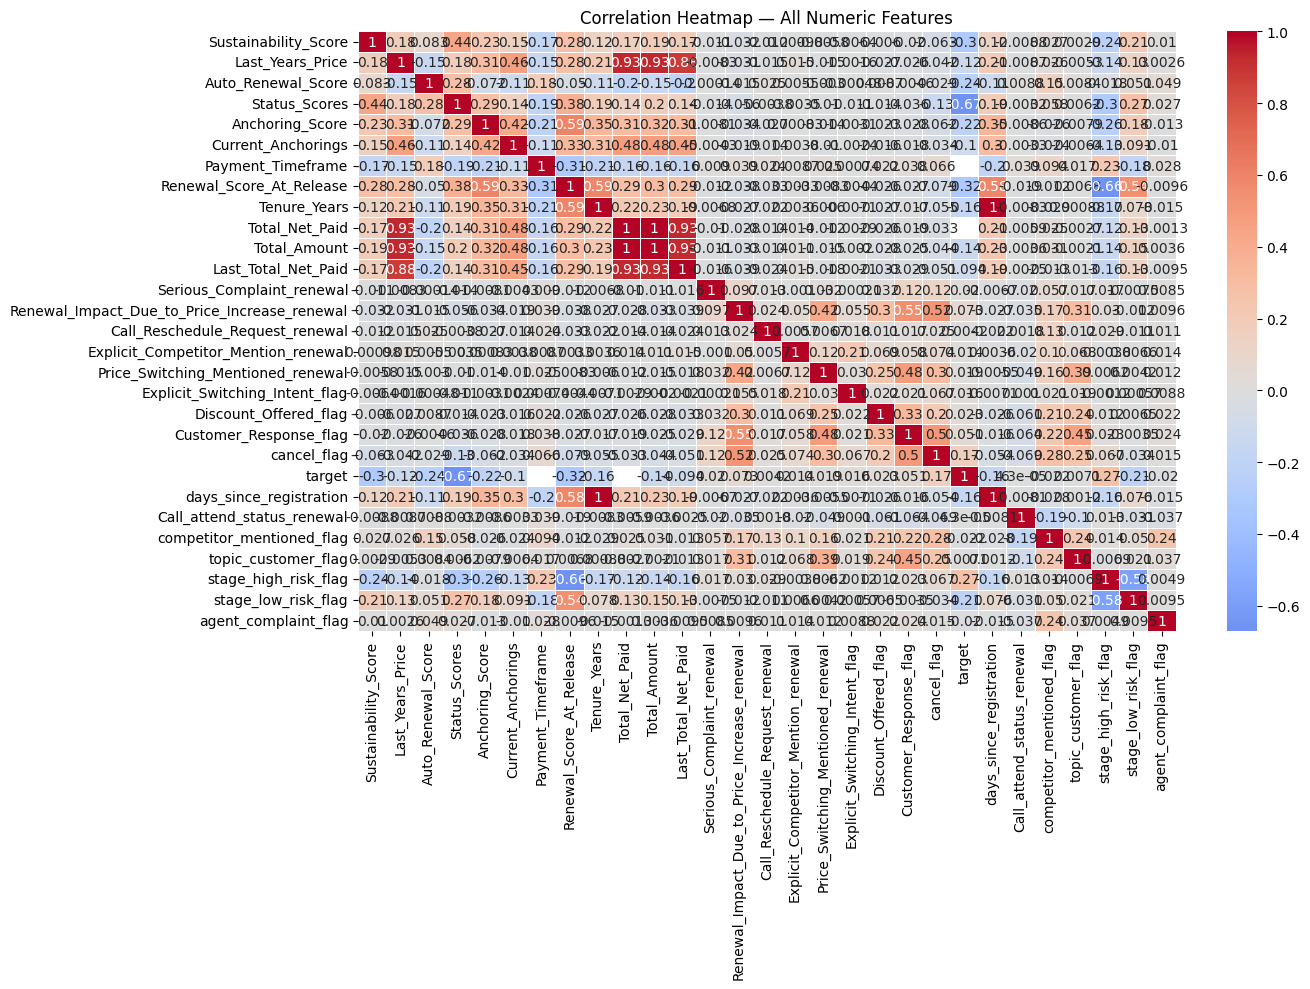

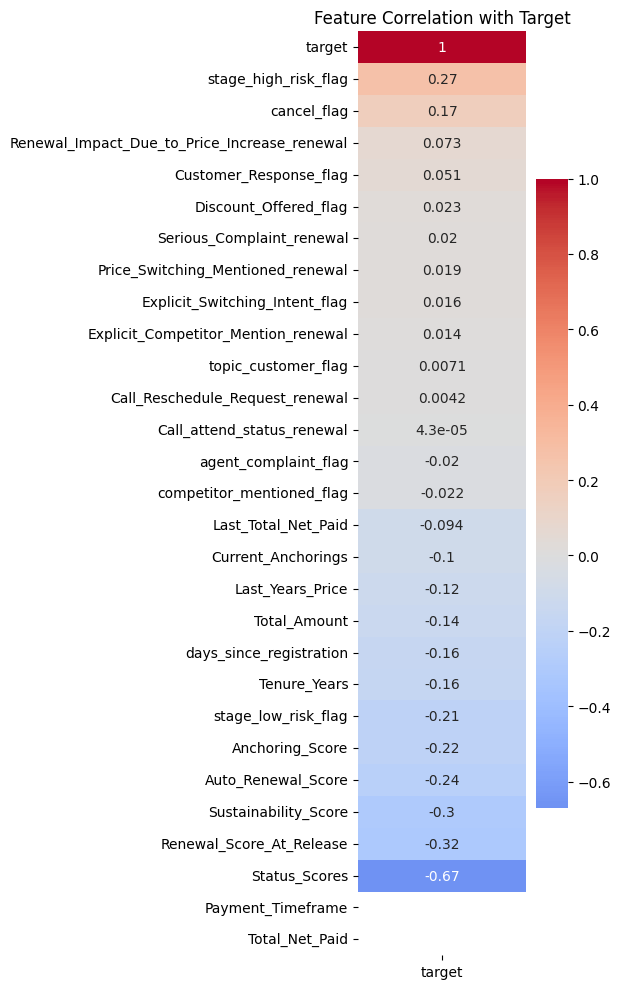

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Correlation Heatmap — All Numeric Features")
plt.tight_layout()
plt.show()

# Focus on target correlation only
corr_target = df.corr(numeric_only=True)[['target']].sort_values(by='target', ascending=False)
plt.figure(figsize=(6, 10))
sns.heatmap(corr_target, annot=True, cmap='coolwarm', center=0)
plt.title("Feature Correlation with Target")
plt.tight_layout()
plt.show()

## 35. Detect Highly Correlated Feature Pairs (>0.9)

Features with absolute correlation > 0.9 are near-duplicates.
Keeping both inflates feature count, confuses feature importance rankings, and adds no new information to the model.

In [115]:
import numpy as np

corr_matrix = df.corr(numeric_only=True).abs()

# Upper triangle only — avoids counting each pair twice
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr = [col for col in upper.columns if any(upper[col] > 0.9)]
print("Highly correlated features (>0.9 with any other feature):", high_corr)

Highly correlated features (>0.9 with any other feature): ['Total_Net_Paid', 'Total_Amount', 'Last_Total_Net_Paid', 'days_since_registration']


## 36. Feature Engineering — Percentage Price Increase

**Hypothesis:** A large price increase relative to last year is a key driver of churn.
Customers who face 'sticker shock' (large % increase) are more likely to cancel
than those whose price barely changed.

The ratio `(Current - Last) / Last` captures this relative shock effect better than the raw difference.

In [116]:
# % price increase: how much more is the customer paying vs last year?
# High % increase → sticker shock → higher churn risk
# Small epsilon (1e-5) prevents division-by-zero for edge cases with £0 last year price
df['pct_inc_total_net_paid'] = (
    (df['Total_Net_Paid'] - df['Last_Total_Net_Paid'])
    / (df['Last_Total_Net_Paid'] + 1e-5)
)

## 37. Drop Redundant Financial & Tenure Columns

**WHY drop `Total_Amount` and `Last_Total_Net_Paid`:**
- `Total_Amount` ≈ `Total_Net_Paid` (correlation ~1.0) — pure duplicate, no new information
- `Last_Total_Net_Paid` is now captured in the percentage increase ratio — keeping the raw value alongside `Total_Net_Paid` creates multicollinearity

**WHY keep `Tenure_Years` and drop `days_since_registration`:**
- Both measure the same thing (customer longevity), so we only need one
- `Tenure_Years` is cleaner — it directly counts years of membership, not calendar days from registration
- `days_since_registration` is noisier (depends on the exact registration date vs. membership start date)

**WHY drop `pct_inc_total_net_paid` later:**
- After reflection, `Total_Net_Paid` alone is sufficient — the model can learn price sensitivity from the raw value; the ratio adds marginal value but creates another collinear feature

In [117]:
# Total_Amount ≈ Total_Net_Paid: near-perfect duplicate — pure multicollinearity
# Last_Total_Net_Paid: now captured in pct_inc_total_net_paid ratio — keeping raw value is redundant
df = df.drop(columns=['Total_Amount', 'Last_Total_Net_Paid'], errors='ignore')

# Prefer Tenure_Years over days_since_registration — cleaner, directly interpretable
df.drop(columns=['days_since_registration'], errors='ignore', inplace=True)

print(f"Columns remaining: {len(df.columns)}")

Columns remaining: 39


## 38. Impute Missing Values

For numeric columns with remaining nulls, use a two-tier imputation strategy:
1. **Group median by `Co_Ref`** (company group): Accounts in the same company tend to have similar financial profiles — group median is more accurate than global median for intra-company patterns.
2. **Global median fallback**: For companies with all-null values in a column.

In [118]:
# Impute Payment Timeframe: company group median → global median
df['Payment_Timeframe'] = df['Payment_Timeframe'].fillna(
    df.groupby('Co_Ref')['Payment_Timeframe'].transform('median')
)
df['Payment_Timeframe'] = df['Payment_Timeframe'].fillna(df['Payment_Timeframe'].median())

# Impute Total Net Paid: company group median → global median
df['Total_Net_Paid'] = df['Total_Net_Paid'].fillna(
    df.groupby('Co_Ref')['Total_Net_Paid'].transform('median')
)
df['Total_Net_Paid'] = df['Total_Net_Paid'].fillna(df['Total_Net_Paid'].median())

# Impute Renewal Score: company group median → global median
df['Renewal_Score_At_Release'] = df['Renewal_Score_At_Release'].fillna(
    df.groupby('Co_Ref')['Renewal_Score_At_Release'].transform('median')
)
df['Renewal_Score_At_Release'] = df['Renewal_Score_At_Release'].fillna(
    df['Renewal_Score_At_Release'].median()
)

# Impute Tenure Years: company group median → global median
df['Tenure_Years'] = df['Tenure_Years'].fillna(
    df.groupby('Co_Ref')['Tenure_Years'].transform('median')
)
df['Tenure_Years'] = df['Tenure_Years'].fillna(df['Tenure_Years'].median())

# Null anchor list = no current anchors → fill with 'None' literal
df['Current_Anchor_List'] = df['Current_Anchor_List'].fillna('None')

# Verify all nulls resolved
for col in df.columns:
    nulls = df[col].isnull().sum()
    if nulls > 0:
        print(f"{col}: {nulls} nulls remaining")

Last_Years_Price: 8817 nulls remaining
Proforma_Auto_Renewal: 18048 nulls remaining
pct_inc_total_net_paid: 52375 nulls remaining


## 39. Drop Co_Ref Company Identifier

**WHY drop:**
- `Co_Ref` was only needed for group-level imputation (done above)
- Keeping it as a feature would allow the model to **memorise company-specific patterns** from the training set → overfitting on company IDs
- In production, we want the model to generalise to *new* companies not seen during training

In [119]:
# Used for group-level imputation — now drop to prevent model memorising company IDs
df.drop(columns=['Co_Ref'], inplace=True)

print(f"Final column count before encoding: {len(df.columns)}")

Final column count before encoding: 38


## 40. Final Data Preparation — Fix Types, Encode, Drop Remaining Columns

Prepare the final feature matrix for XGBoost:
1. **Fix `Discount_Amount`** — stored as string with '%' character, convert to float
2. **Binary string columns** (`y/n`) → 0/1 integers
3. **Drop `Current_Anchor_List`** — too many unique text values; one-hot would explode dimensionality; label encoding would impose false ordinal meaning on arbitrary strings
4. **Encode `Proforma_Auto_Renewal`** string to binary
5. **Drop `Last_Years_Price`** — already represented by `Total_Net_Paid` + price increase ratio
6. **Drop `pct_inc_total_net_paid`** — marginal value; `Total_Net_Paid` carries sufficient financial signal
7. **One-hot encode** low-cardinality categoricals (≤20 unique values)
8. **Label encode** high-cardinality categoricals (>20 unique values) — prevents dimension explosion

In [120]:
from sklearn.preprocessing import LabelEncoder

# Fix Discount_Amount: stored as '15%' string format → convert to float 15.0
df['Discount_Amount'] = pd.to_numeric(
    df['Discount_Amount'].astype(str).str.replace('%', ''), errors='coerce'
)

# Binary string columns: 'y'/'n' or 'yes'/'no' → 1/0
binary_map = {'y': 1, 'n': 0, 'yes': 1, 'no': 0}
for col in ['Current_Auto_Renewal_Flag', 'Current_World_Pay_Token']:
    df[col] = df[col].astype(str).str.lower().map(binary_map).fillna(0).astype(int)

# Drop anchor list: too many unique strings (~1000s) — one-hot would explode dimension count
df.drop(columns=['Current_Anchor_List'], inplace=True, errors='ignore')

# Encode Auto Renewal as binary
df['Proforma_Auto_Renewal'] = (
    df['Proforma_Auto_Renewal']
    .fillna('no')  # handle NaN first
    .astype(str)
    .str.lower()
    .apply(lambda x: 1 if 'yes' in x else 0)
)

# Drop remaining redundant financial columns
df = df.drop(columns='Last_Years_Price', errors='ignore')
df.drop(columns=['pct_inc_total_net_paid'], inplace=True, errors='ignore')

# Cast remaining object columns to category for efficient encoding
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category')

# Encode categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()
cat_cols = df.select_dtypes(include=['category']).columns.tolist()
if 'target' in cat_cols:
    cat_cols.remove('target')

for col in cat_cols:
    unique_vals = df[col].nunique()
    if unique_vals <= 20:
        # One-hot encode: interpretable binary dummies, avoids false ordinality
        df = pd.get_dummies(df, columns=[col], drop_first=True)
    else:
        # Label encode: avoids dimension explosion for high-cardinality columns
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

print("Remaining object columns (should be empty):", df.select_dtypes(include='object').columns.tolist())
print("Final dataset shape:", df.shape)


df.to_csv("../../dataset/06_model_dataset/model_data.csv")

C:\Users\Asus\AppData\Local\Temp\ipykernel_26132\814332955.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


Remaining object columns (should be empty): []
Final dataset shape: (113894, 65)


## 41. Train/Test Split & XGBoost Model Training

**Why XGBoost?**
- Handles mixed numeric and encoded categorical features naturally
- Tree-based — robust to outliers and non-linear relationships
- `scale_pos_weight` corrects for class imbalance: tells the model churned customers are rarer but more important to get right

**`scale_pos_weight` formula:** `(# negatives) / (# positives)` — the larger this ratio, the more the model is penalised for missing a churner.

In [121]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

X = df.drop(columns=['target'])
y = df['target']

# Stratified split preserves churn ratio in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Compensate for class imbalance — churners are rarer but more important to detect
scale_pos_weight = (y == 0).sum() / (y == 1).sum()
print(f"Class imbalance ratio (scale_pos_weight): {scale_pos_weight:.2f}")

model = XGBClassifier(
    n_estimators=500,
    max_depth=4,          # Shallow trees = less overfitting
    learning_rate=0.1,
    subsample=0.8,        # Use 80% of rows per tree — reduces variance
    colsample_bytree=0.8, # Use 80% of features per tree — reduces variance
    scale_pos_weight=scale_pos_weight
)

model.fit(X_train, y_train)
print("Model training complete.")

Class imbalance ratio (scale_pos_weight): 7.99
Model training complete.


## 42. Find Optimal Classification Threshold

**WHY tune the threshold?**
- Default threshold of 0.5 optimises for balanced accuracy — suboptimal for churn problems
- For churn, we typically prioritise **recall** (catching real churners) over precision (avoiding false alarms)
- We find the threshold that maximises F1 score — the harmonic mean of precision and recall

**Adjust the final threshold** based on business context:
- Lower threshold → catch more churners (higher recall, more false alarms)
- Higher threshold → fewer false alarms (higher precision, miss more real churners)

In [122]:
from sklearn.metrics import precision_recall_curve
import numpy as np

y_prob = model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# F1 = harmonic mean of precision and recall — best single metric for imbalanced classification
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best Threshold (maximises F1): {best_threshold:.4f}")
print(f"Best F1 Score: {f1_scores[best_idx]:.4f}")

Best Threshold (maximises F1): 0.7880
Best F1 Score: 0.8648


## 43. Model Evaluation

Evaluate using a custom threshold (set lower than 0.5 to prioritise recall for churn use case).

**Key metrics to focus on for churn:**
- **Recall (class 1):** What % of actual churners did we correctly flag?
- **Precision (class 1):** Of the customers we flagged as at-risk, what % actually churned?
- **ROC AUC:** Overall discriminative ability across all possible thresholds

In [123]:
from sklearn.metrics import classification_report, roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]

# Adjust threshold based on business need:
# Lower → catch more churners (higher recall, more false alarms)
# Higher → fewer false alarms (higher precision, miss more churners)
threshold = 0.05

y_pred = (y_prob > threshold).astype(int)

print(f"Threshold used: {threshold}")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Threshold used: 0.05
              precision    recall  f1-score   support

           0       1.00      0.80      0.89     20245
           1       0.38      0.99      0.55      2534

    accuracy                           0.82     22779
   macro avg       0.69      0.89      0.72     22779
weighted avg       0.93      0.82      0.85     22779

ROC AUC: 0.988969330515705


## 44. Sanity Check — Manual Prediction Test

Manually test the model on hand-crafted cases to confirm predictions align with business logic:

- **Non-Churn case:** Long-tenure customer, auto-renewing, no complaints, no competitor signals → should predict low churn probability
- **Strong Churn case:** New customer, serious complaint, competitor mentioned, price switching discussed, high-risk stage → should predict high churn probability

In [124]:
# sample_non_churn_full = {
#  'Discount_Amount': 0.0, 'Sustainability_Score': 9.5, 'Auto_Renewal_Score': 9,
#  'Status_Scores': 9, 'Anchoring_Score': 9.0, 'Proforma_Auto_Renewal': 0,
#  'Current_Anchorings': 2, 'Payment_Timeframe': 0.0, 'Current_Auto_Renewal_Flag': 1,
#  'Current_World_Pay_Token': 1, 'Renewal_Score_At_Release': 27.0, 'Tenure_Years': 5,
#  'Total_Net_Paid': 700, 'Serious_Complaint_renewal': 0,
#  'Renewal_Impact_Due_to_Price_Increase_renewal': 0, 'Call_Reschedule_Request_renewal': 0,
#  'Explicit_Competitor_Mention_renewal': 0, 'Price_Switching_Mentioned_renewal': 0,
#  'Explicit_Switching_Intent_flag': 0, 'Discount_Offered_flag': 0,
#  'Customer_Response_flag': 0, 'cancel_flag': 0, 'Call_attend_status_renewal': 1,
#  'competitor_mentioned_flag': 0, 'topic_customer_flag': 0,
#  'stage_high_risk_flag': 0, 'stage_low_risk_flag': 1, 'agent_complaint_flag': 0,
#  'Band_Band B': 0, 'Band_Band C1': 0, 'Band_Band C2': 0, 'Band_Band D': 1,
#  'Band_Band E': 0, 'Band_Band F': 0, 'Band_Band F1': 0, 'Band_Band F2': 0,
#  'Band_Band G': 0, 'Band_Band H': 0, 'Band_Band I': 0, 'Band_Band J': 0,
#  'Band_Group': 0, 'Band_Unknown': 0,
#  'Connection_Group_10+': 0, 'Connection_Group_2': 0, 'Connection_Group_3': 1,
#  'Connection_Group_4-9': 0, 'Connection_Group_Unknown': 0, 'Connection_Group_independent': 0,
#  'Tenure_Group_2': 0, 'Tenure_Group_3': 0, 'Tenure_Group_4+': 1, 'Tenure_Group_Unknown': 0,
#  'Anchor_Group_10+': 0, 'Anchor_Group_2': 0, 'Anchor_Group_3': 1,
#  'Anchor_Group_4-9': 0, 'Anchor_Group_Unknown': 0, 'Anchor_Group_independent': 0,
#  'Competitor_Value_Comparison_renewal_not discussed': 0,
#  'Competitor_Value_Comparison_renewal_similar value': 0,
#  'Competitor_Value_Comparison_renewal_unknown': 1,
#  'Customer_Response_Risk_Low Risk': 1, 'Customer_Response_Risk_Medium Risk': 0,
#  'Customer_Response_Risk_Neutral': 0
# }

# sample_churn_strong = {
#  'Discount_Amount': 50.0, 'Sustainability_Score': 6.0, 'Auto_Renewal_Score': 5,
#  'Status_Scores': 0, 'Anchoring_Score': 6.5, 'Proforma_Auto_Renewal': 0,
#  'Current_Anchorings': 0, 'Payment_Timeframe': 5.0, 'Current_Auto_Renewal_Flag': 0,
#  'Current_World_Pay_Token': 0, 'Renewal_Score_At_Release': 20.0, 'Tenure_Years': 1,
#  'Total_Net_Paid': 200, 'Serious_Complaint_renewal': 1,
#  'Renewal_Impact_Due_to_Price_Increase_renewal': 1, 'Call_Reschedule_Request_renewal': 1,
#  'Explicit_Competitor_Mention_renewal': 1, 'Price_Switching_Mentioned_renewal': 1,
#  'Explicit_Switching_Intent_flag': 1, 'Discount_Offered_flag': 1,
#  'Customer_Response_flag': 1, 'cancel_flag': 0, 'Call_attend_status_renewal': 0,
#  'competitor_mentioned_flag': 1, 'topic_customer_flag': 1,
#  'stage_high_risk_flag': 1, 'stage_low_risk_flag': 0, 'agent_complaint_flag': 1,
#  'Band_Band B': 0, 'Band_Band C1': 1, 'Band_Band C2': 0, 'Band_Band D': 0,
#  'Band_Band E': 0, 'Band_Band F': 0, 'Band_Band F1': 0, 'Band_Band F2': 0,
#  'Band_Band G': 0, 'Band_Band H': 0, 'Band_Band I': 0, 'Band_Band J': 0,
#  'Band_Group': 0, 'Band_Unknown': 0,
#  'Connection_Group_10+': 0, 'Connection_Group_2': 1, 'Connection_Group_3': 0,
#  'Connection_Group_4-9': 0, 'Connection_Group_Unknown': 0, 'Connection_Group_independent': 0,
#  'Tenure_Group_2': 1, 'Tenure_Group_3': 0, 'Tenure_Group_4+': 0, 'Tenure_Group_Unknown': 0,
#  'Anchor_Group_10+': 0, 'Anchor_Group_2': 1, 'Anchor_Group_3': 0,
#  'Anchor_Group_4-9': 0, 'Anchor_Group_Unknown': 0, 'Anchor_Group_independent': 0,
#  'Competitor_Value_Comparison_renewal_not discussed': 0,
#  'Competitor_Value_Comparison_renewal_similar value': 1,
#  'Competitor_Value_Comparison_renewal_unknown': 0,
#  'Customer_Response_Risk_Low Risk': 0, 'Customer_Response_Risk_Medium Risk': 1,
#  'Customer_Response_Risk_Neutral': 0
# }

# test_df = pd.DataFrame([sample_non_churn_full, sample_churn_strong])
# test_df.index = ['Non-Churn Example', 'Strong Churn Example']

# preds = model.predict(test_df)
# probs = model.predict_proba(test_df)[:, 1]

# test_df['prediction'] = preds
# test_df['churn_probability'] = probs

# print(test_df[['prediction', 'churn_probability']])

## 45. Feature Importance Analysis

Inspect the top 20 most important features as ranked by XGBoost.

**WHY this step matters:**
- Validates the model is using genuine business signals (not noise or data leakage)
- If an administrative/ID column ranks highly → investigate for leakage
- Guides future data collection: the highest-importance features are worth investing in quality

Top 20 Feature Importances:
Status_Scores                0.422602
Sustainability_Score         0.070414
Auto_Renewal_Score           0.052061
Connection_Group_Unknown     0.027556
Current_Auto_Renewal_Flag    0.026311
Current_World_Pay_Token      0.025148
cancel_flag                  0.023553
Tenure_Years                 0.021317
Discount_Amount              0.019887
stage_high_risk_flag         0.018596
Band_Band F                  0.018250
Total_Net_Paid               0.018223
Band_Band B                  0.013919
Band_Band C1                 0.010258
Payment_Timeframe            0.010226
Tenure_Group_4+              0.009158
Anchor_Group_Unknown         0.009118
Renewal_Score_At_Release     0.009014
Anchor_Group_independent     0.008960
Tenure_Group_3               0.008916
dtype: float32


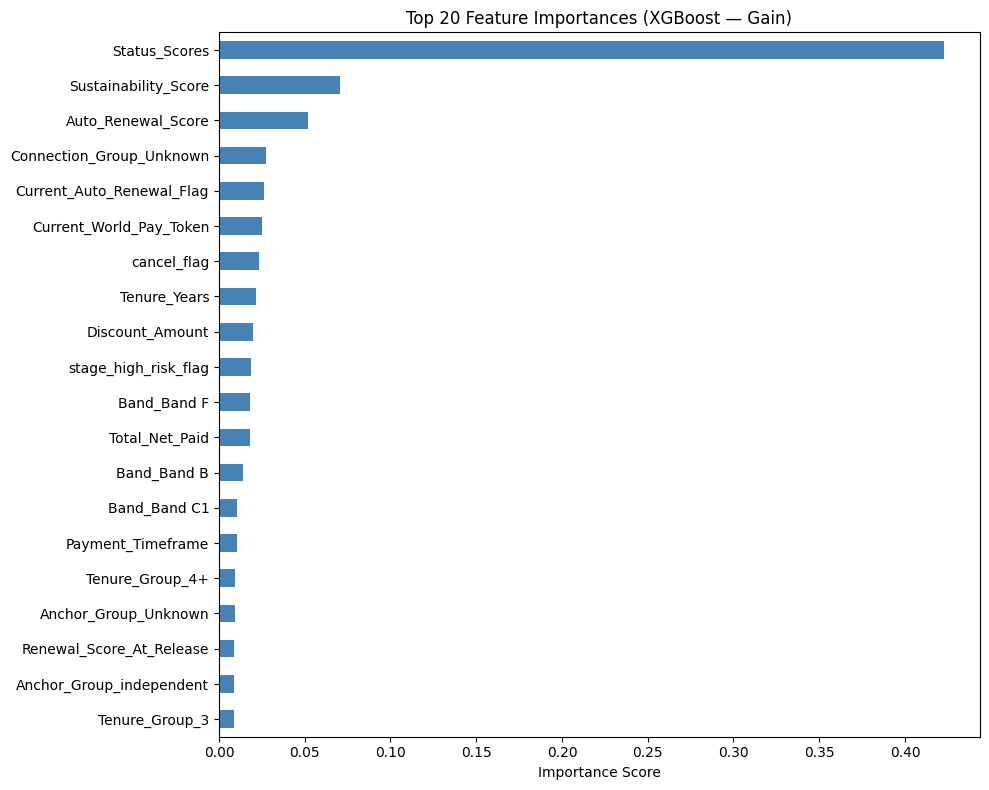

In [125]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=X.columns)
top_features = importance.sort_values(ascending=False).head(20)

print("Top 20 Feature Importances:")
print(top_features)

plt.figure(figsize=(10, 8))
top_features.sort_values().plot(kind='barh', color='steelblue')
plt.title("Top 20 Feature Importances (XGBoost — Gain)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()